In [1]:
import sympy
from sympy import *
init_printing()
from IPython.display import display

# Vectorized Member Result Extraction

For models with a large number of load cases, splitting members into mathematically continuous sections is very slow. Sometimes all we want to do is extract member forces at numerous points along the member length in order to say plot the results. In such cases it is much quicker to extract the results directly to numpy arrays without first splitting the member into segments. This notebook derives the equations to extract member moments and deflections for distributed member loads. 

To start with, we'll define a beam sign convention:
<div>
    <img src="../Resources/Member Local Coordinates.png" width=500/>
</div>

## Distributed Load Beam Moments

The equation for a linear distributed load is expressed as follows:

In [13]:
w, w1, w2, x, L = symbols('omega, omega_1, omega_2, x, L')
w = w1 + (w2-w1)/L*x
display(Eq(symbols('\\omega(x)'), w))

Where:

$\omega_1=$ magnitude of distributed load at starting point

$\omega_2=$ magnitude of distributed laod at ending point

$x_1=$ distributed load starting point

$x_2=$ distributed load ending point

In order to calculate the beam moments induced by a distributed load with w1 == w2, x1 == 0 and x2 == L (the trivial case) we can us the following equation:

In [14]:
w, M, x, L = symbols('omega, M, x, L')
M = w * x * (L - x) / 2
display(Eq(symbols('M(x)'), M))

To derive the beam moment equations for situations where the above does not hold true, we can assume the distributed load to be a series of infinetely many point loads of varying magnitudes. We can then sum the moment produced by each of these points loads to obtain the moment produced by the original distributed load.
The equation for the moment induced by a point load at any distance along a beam (a) is :

In [19]:
P, M1, M2, a, x, L = symbols('P, M1, M2, a, x, L')
M1 = P*(L-a)*x/L
M2 = P*a*(L-x)/L
display(Eq(symbols('M1(x)'), M1), "Where x<a")
display(Eq(symbols('M2(x)'), M2), "Where x>=")

'Where x<a'

'Where x>='

Assuming w1 == w2, lets integrate these equations between x1 and x2:

In [ ]:
w1, w2, w_a ,x1 , x2 = symbols('omega_1, omega_2, w_a, x1, x2')
M1, M2, Ml, Mm, Mr, a, x, L = symbols('M1, M2, Ml, Mm, Mr, a, x, L')

w_a = w1 #as load is constant
M1 = w_a*(L-a)*x/L
M2 = w_a*a*(L-x)/L

Ml = integrate(M1, (a, x1, x2))
display(Eq(symbols('M_left(x)'), Ml), "Where x<w1")

Mm = integrate(M2, (a, x1, x)) + integrate(M1, (a, x, x2))
display(Eq(symbols('M_mid(x)'), Mm), "Where x>=x1 and x<x2")

Mr = integrate(M2, (a, x1, x2))
display(Eq(symbols('M_right(x)'), Mr), "Where x>=w2")

'Where x<w1'

'Where x>=x1 and x<x2'

'Where x>=w2'

Now we can cover the less common case where w1 != w2. We can make w_a a function of x and integrate as above:

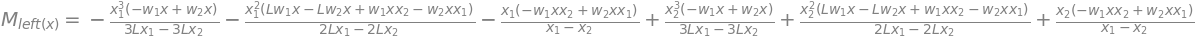

'Where x<w1'

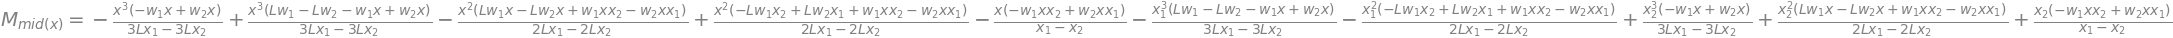

'Where x>=x1 and x<x2'

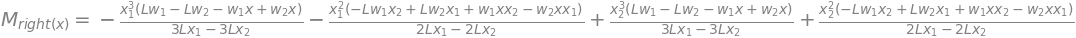

'Where x>=w2'

In [61]:
w1, w2, w_a ,x1 , x2 = symbols('w1, w2, w_a, x1, x2')
M1, M2, Ml, Mm, Mr, a, x, L = symbols('M1, M2, Ml, Mm, Mr, a, x, L')

w_a = w1 + (w2-w1)* (a-x1)/(x2-x1)
M1 = w_a*(L-a)*x/L
M2 = w_a*a*(L-x)/L

Ml = integrate(M1, (a, x1, x2))
display(Eq(symbols('M_left(x)'), Ml), "Where x<w1")

Mm = integrate(M2, (a, x1, x)) + integrate(M1, (a, x, x2))
display(Eq(symbols('M_mid(x)'), Mm), "Where x>=x1 and x<x2")

Mr = integrate(M2, (a, x1, x2))
display(Eq(symbols('M_right(x)'), Mr), "Where x>=w2")

## Distributed Load Beam Deflections

We can complete the same process as above for beam deflections. For the trivial case, we can use the equation below.

In [44]:
w, d, x, L, EI = symbols('omega, d, x, L, EI')
d = 5*w*L**4/(384*EI)
display(Eq(symbols('d(x)'), d))

As for the moments, we can generate the equations for deflection from the equation for deflection of a beam under a point load. 

In [45]:
P, d1, d2, a, x, L = symbols('P, d1, d2, a, x, L')
d1 = P*(L-a)*x*(L**2-(L-a)**2-x**2)/(6*EI*L)
d2 = P*a*(L-x)*(L**2-a**2-(L-x)**2)/(6*EI*L)
display(Eq(symbols('d1(x)'), d1), "Where x<a")
display(Eq(symbols('d2(x)'), d2), "Where x>=")

'Where x<a'

'Where x>='

Assuming w1 == w2, lets integrate these equations between x1 and x2:

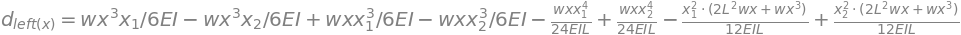

'Where x<w1'

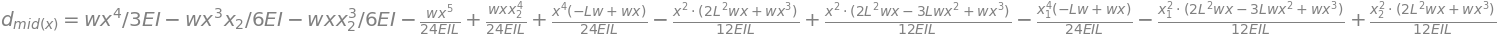

'Where x>=x1 and x<x2'

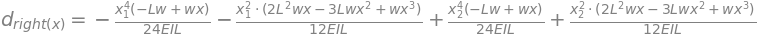

'Where x>=w2'

In [59]:
w1, w2, w_a, w ,x1, x2 = symbols('omega_1, omega_2, w_a, w, x1, x2')
d1, d2, dl, dm, dr, a, x, L = symbols('d1, d2, dl, dm, dr, a, x, L')

w_a = w #as load is constant
d1 = w*(L-a)*x*(L**2-(L-a)**2-x**2)/(6*EI*L)
d2 = w*a*(L-x)*(L**2-a**2-(L-x)**2)/(6*EI*L)

dl = integrate(d1, (a, x1, x2))
display(Eq(symbols('d_left(x)'), dl), "Where x<w1")

dm = integrate(d2, (a, x1, x)) + integrate(d1, (a, x, x2))
display(Eq(symbols('d_mid(x)'), dm), "Where x>=x1 and x<x2")

dr = integrate(d2, (a, x1, x2))
display(Eq(symbols('d_right(x)'), dr), "Where x>=w2")


Now we can cover the less common case where w1 != w2. We can make w_a a function of x and integrate as above:

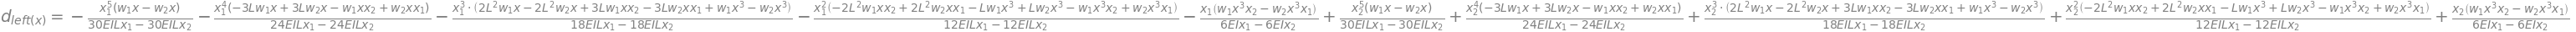

'Where x<w1'

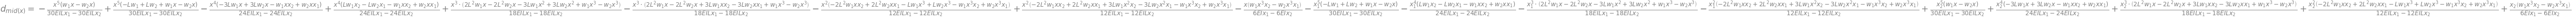

'Where x>=x1 and x<x2'

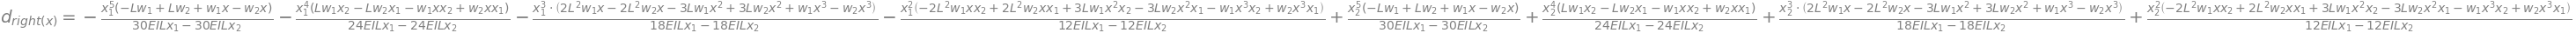

'Where x>=w2'

In [60]:
w1, w2, w_a, w ,x1, x2 = symbols('w1, w2, w_a, w, x1, x2')
d1, d2, dl, dm, dr, a, x, L = symbols('d1, d2, dl, dm, dr, a, x, L')

w_a = w1 + (w2-w1)* (a-x1)/(x2-x1)
d1 = w_a*(L-a)*x*(L**2-(L-a)**2-x**2)/(6*EI*L)
d2 = w_a*a*(L-x)*(L**2-a**2-(L-x)**2)/(6*EI*L)

dl = integrate(d1, (a, x1, x2))
display(Eq(symbols('d_left(x)'), dl), "Where x<w1")

dm = integrate(d2, (a, x1, x)) + integrate(d1, (a, x, x2))
display(Eq(symbols('d_mid(x)'), dm), "Where x>=x1 and x<x2")

dr = integrate(d2, (a, x1, x2))
display(Eq(symbols('d_right(x)'), dr), "Where x>=w2")
